In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

%matplotlib inline

In [3]:
df = pd.read_csv("D:\Data Science projects\House Pricing 2\Datasets\house-pricing-datasets-2\house_prices.csv")
df 

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_22180\1620847993.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("D:\Data Science projects\House Pricing 2\Datasets\house-pricing-datasets-2\house_prices.csv")


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,N,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,N,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,N,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,N,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,N,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,N,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,N,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,N,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,N,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


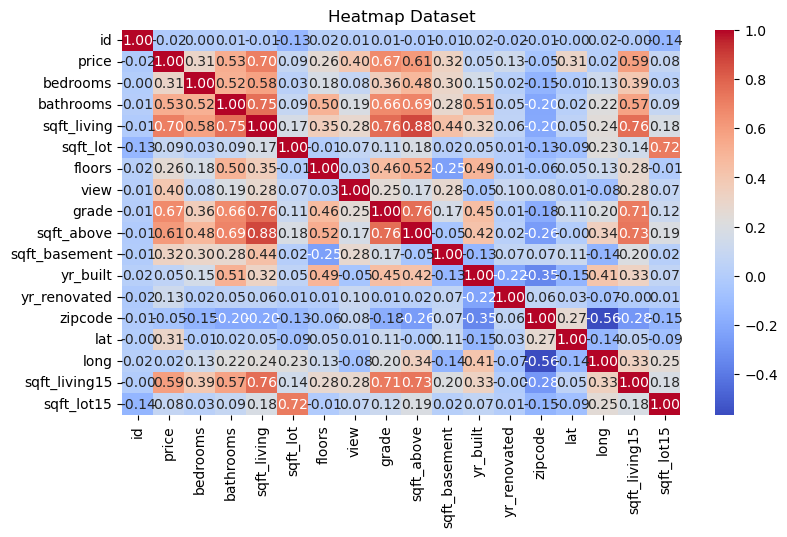

In [4]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(9, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Dataset")
plt.show()  

In [5]:
df['waterfront'] = df['waterfront'].map({'N': 0, 'Y': 1})

In [6]:
features = ['sqft_living', 'grade', 'sqft_above', 'bathrooms', 'view', 
            'sqft_living15', 'lat', 'long', 'waterfront', 'yr_built', 'bedrooms']

X = df[features]
y = np.log1p(df['price']) # Teknik Log Transform

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
model_final = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42)
model_final.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=200, random_state=42)

In [9]:
predictions = model_final.predict(X_test)
print(f"Akurasi Baru: {r2_score(y_test, predictions) * 100:.2f}%")

Akurasi Baru: 88.52%


In [22]:
y_test_original = np.expm1(y_test)
predictions_original = np.expm1(predictions)

In [24]:
residuals = y_test_original - predictions_original

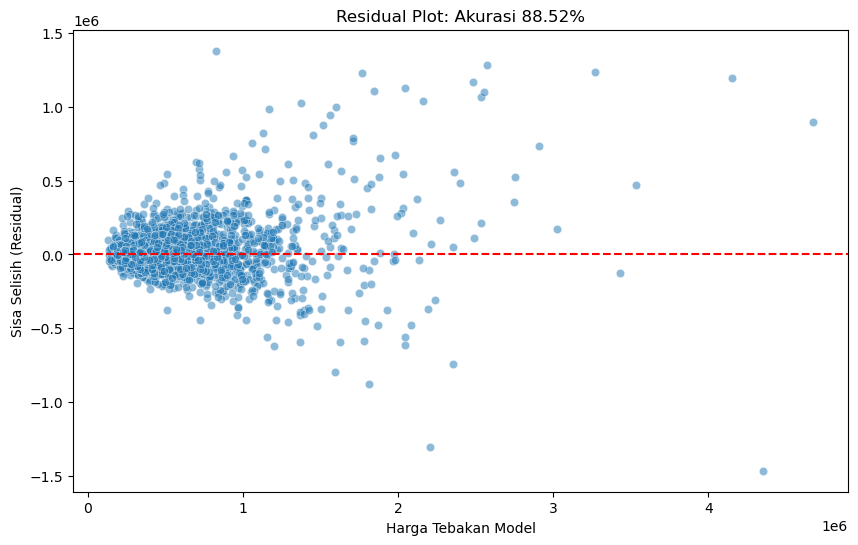

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=predictions_original, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--') # Garis horizontal di angka 0
plt.xlabel('Harga Tebakan Model')
plt.ylabel('Sisa Selisih (Residual)')
plt.title('Residual Plot: Akurasi 88.52%')
plt.show()

In [30]:
df_eval = X_test.copy()
df_eval['harga_asli'] = y_test_original
df_eval['harg_tebakan'] = predictions_original
df_eval['selisih_error'] = residuals

In [34]:
print("--- 5 Rumah yang Menebak Terlalu Murah (Error Positif) ---")
display(df_eval.sort_values(by='selisih_error', ascending=False).head(5))

--- 5 Rumah yang Menebak Terlalu Murah (Error Positif) ---


,sqft_living,grade,sqft_above,bathrooms,view,sqft_living15,lat,long,waterfront,yr_built,bedrooms,harga_asli,harg_tebakan,selisih_error
19684,3430,10,3430,2.50,0,3110,47.7159,-122.251,0,2014,3,2205000.0,8.261595e+05,1.378841e+06
2085,5770,11,5770,4.25,4,4620,47.5850,-122.222,1,1980,4,3850000.0,2.569951e+06,1.280049e+06
2626,6640,12,6350,5.50,4,3030,47.7493,-122.280,1,2004,5,4500000.0,3.266822e+06,1.233178e+06
11257,4850,10,3850,4.25,4,3350,47.7011,-122.244,1,1989,4,3000000.0,1.768940e+06,1.231060e+06
1448,8000,12,6720,5.00,4,4600,47.6232,-122.220,0,2009,5,5350000.0,4.154672e+06,1.195328e+06


In [36]:
print("\n--- 5 Rumah yang Menebak Terlalu Mahal (Error Negatif) ---")
display(df_eval.sort_values(by='selisih_error', ascending=True).head(5))


--- 5 Rumah yang Menebak Terlalu Mahal (Error Negatif) ---


,sqft_living,grade,sqft_above,bathrooms,view,sqft_living15,lat,long,waterfront,yr_built,bedrooms,harga_asli,harg_tebakan,selisih_error
14556,8670,13,6120,6.25,4,4140,47.7295,-122.372,0,1965,5,2888000.0,4.352004e+06,-1.464004e+06
21050,7120,12,5480,6.00,4,3440,47.5451,-122.114,0,2007,5,900000.0,2.204484e+06,-1.304484e+06
14463,3530,9,3530,2.00,0,4100,47.5774,-122.285,0,1925,5,930000.0,1.809925e+06,-8.799254e+05
4024,7480,11,5080,6.75,2,2810,47.4643,-122.368,0,1953,7,800000.0,1.593239e+06,-7.932390e+05
14774,5470,11,3730,2.75,4,3620,47.5316,-122.263,1,1992,4,1612500.0,2.351226e+06,-7.387264e+05
